In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class MultiScaleFHRRMap(nn.Module):
    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu"):
        super().__init__()

        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        # Random FHRR phases for spatial axes at each scale
        axis_phase = 2 * torch.pi * torch.rand(
            self.num_scales, spatial_dim, dim, device=device
        ) - torch.pi

        # Class and scale role vectors
        class_phase = 2 * torch.pi * torch.rand(
            num_classes, dim, device=device
        ) - torch.pi

        scale_phase = 2 * torch.pi * torch.rand(
            self.num_scales, dim, device=device
        ) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("class_vecs", torch.exp(1j * class_phase))
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        # Learnable scale mixture weights
        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales))

    def encode_position(self, x):
        """
        x: [N, spatial_dim]
        returns: [N, K, D]
        """

        # phase[n, k, d] = sum_j x[n,j] * theta[k,j,d] / lengthscale[k]
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]

        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)

        return torch.exp(1j * phase)

    def build_memory(self, points, labels, point_weights=None, normalize_by_class=False):
        """
        points: [N, spatial_dim]
        labels: [N]
        point_weights: optional [N]
        normalize_by_class: if False (default), every point's record contributes
            equal energy to the memory, so a class with more points (e.g. "room")
            dominates the bundle purely by count. If True, records are summed per
            class first and each class's sum is normalized to unit norm before
            being added to the memory, so every class contributes equally
            regardless of how many points it had (mirrors
            ``VSASpatialMemory.fit(normalize_by_class=...)`` in
            ``models/baseline.py``).
        returns memory: [D]
        """

        pos = self.encode_position(points)  # [N, K, D]

        class_vec = self.class_vecs[labels]  # [N, D]
        scale_vec = self.scale_vecs          # [K, D]

        atoms = (
            pos
            * class_vec[:, None, :]
            * scale_vec[None, :, :]
        )  # [N, K, D]

        scale_weights = F.softmax(self.scale_logits, dim=0)  # [K]

        atoms = atoms * scale_weights[None, :, None]

        if point_weights is not None:
            atoms = atoms * point_weights[:, None, None]

        records = atoms.sum(dim=1)  # [N, D] -- per-point record, summed over scales

        if normalize_by_class:
            memory = torch.zeros(self.dim, dtype=records.dtype, device=records.device)
            for c in torch.unique(labels):
                class_sum = records[labels == c].sum(dim=0)  # [D]
                memory = memory + class_sum / torch.linalg.norm(class_sum)
        else:
            memory = records.sum(dim=0)  # [D]

        # L2 normalize, but do not project elementwise to unit magnitude.
        memory = memory / torch.linalg.norm(memory)

        return memory

    def score_classes(self, memory, query_points):
        """
        memory: [D]
        query_points: [N, spatial_dim]
        returns: class scores [N, C]
        """

        pos = self.encode_position(query_points)  # [N, K, D]

        # probes[n, k, c, d]
        probes = (
            pos[:, :, None, :]
            * self.scale_vecs[None, :, None, :]
            * self.class_vecs[None, None, :, :]
        )

        # complex inner product similarity
        sims = torch.real(
            torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)
        ) / self.dim  # [N, K, C]

        # Sum evidence over scales
        scores = sims.sum(dim=1)  # [N, C]

        return scores

    def predict_proba(self, memory, query_points, temperature=1.0):
        """
        Class probabilities at each query point, mirroring
        ``VSASpatialMemory.query(..., temperature=...)`` in ``models/baseline.py``.

        ``score_classes``'s raw scores are tiny in magnitude (its ``/ self.dim``
        divisor is a much bigger normalizer than the actual signal it's dividing),
        so a softmax at the implicit temperature=1 used during training is nearly
        uniform everywhere -- fine for argmax-based accuracy (only the ranking
        matters), but it flattens the per-class probability maps used for KL
        comparisons against ground truth. Dividing by a small ``temperature``
        rescales the scores back into a range where softmax is actually
        informative.
        """
        scores = self.score_classes(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)

In [3]:
class MultiScaleFHRRMapLearnedTemp(MultiScaleFHRRMap):
    """MultiScaleFHRRMap with a learnable temperature folded directly into the
    training loss. Raw FHRR correlation scores are O(1/sqrt(dim)) in magnitude,
    so an untempered F.cross_entropy sees a near-uniform softmax regardless of
    which class is correct, and scale_logits gets almost no gradient signal --
    see hierarchical_encoding.ipynb's Tier 3 for where this was first found."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memory, query_points):
        return self.score_classes(memory, query_points) / self.temperature


def train_learned_temp(model, build_fn, score_fn_name, train_points, train_labels,
                        val_points, val_labels, class_weights, n_epochs=200, lr=0.05):
    """Generic tempered training loop: build_fn(points, labels) -> memory (or
    memories), score_fn_name is the model method name that divides raw scores
    by the learned temperature. Returns a history dict shaped like the
    untempered `history`/`history_pcmem` dicts elsewhere in this notebook."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "temperature": []}
    scaled_scores = getattr(model, score_fn_name)
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = build_fn(train_points, train_labels)
        train_scores = scaled_scores(memory, train_points)
        train_loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            memory = build_fn(train_points, train_labels)
            val_scores = scaled_scores(memory, val_points)
            val_loss = F.cross_entropy(val_scores, val_labels, weight=class_weights)
            train_acc = (train_scores.argmax(-1) == train_labels).float().mean().item()
            val_acc = (val_scores.argmax(-1) == val_labels).float().mean().item()

        history["train_loss"].append(train_loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["temperature"].append(model.temperature.item())

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(
                f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  val_loss={val_loss.item():.4f}  "
                f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  temperature={model.temperature.item():.4g}"
            )
    return history

## Loading the room environment dataset

Pull labeled points from `RoomEnv.dense_positions()` (the same ground-truth
source `VSASpatialMemory.from_room` uses in `models/baseline.py`), then split
into a fixed train/val set. The split is stratified per label since the room
is heavily imbalanced (e.g. thousands of "room" points vs. ~80 "donut"
points) — a plain random split could otherwise leave a rare class with too
few (or zero) validation points.

In [4]:
import numpy as np

from multiscalessps.envs.room import DEFAULT_LENGTH_SCALES, make_default_room

device = "cpu"
val_frac = 0.2
split_seed = 0

room = make_default_room()

positions = room.dense_positions()
xy = np.array([p for p, _ in positions], dtype=np.float32)
label_strs = [label for _, label in positions]

label_names = sorted(set(label_strs))
name_to_idx = {name: i for i, name in enumerate(label_names)}
labels_idx = np.array([name_to_idx[l] for l in label_strs], dtype=np.int64)

# Stratified train/val split: split each label's indices separately so every
# class (including rare ones like "donut") is represented in both sets.
rng = np.random.default_rng(split_seed)
train_idx, val_idx = [], []
for idx in name_to_idx.values():
    class_positions = np.flatnonzero(labels_idx == idx)
    rng.shuffle(class_positions)
    n_val = max(1, int(round(val_frac * len(class_positions))))
    val_idx.append(class_positions[:n_val])
    train_idx.append(class_positions[n_val:])
train_idx = np.concatenate(train_idx)
val_idx = np.concatenate(val_idx)

train_points = torch.tensor(xy[train_idx], device=device)
train_labels = torch.tensor(labels_idx[train_idx], device=device)
val_points = torch.tensor(xy[val_idx], device=device)
val_labels = torch.tensor(labels_idx[val_idx], device=device)

print(f"labels: {label_names}")
print(f"train points: {len(train_idx)}, val points: {len(val_idx)}")
for name, idx in name_to_idx.items():
    print(f"  {name:>6s}: train={int((train_labels == idx).sum())}, val={int((val_labels == idx).sum())}")

labels: ['donut', 'floor', 'room', 'wall']
train points: 3325, val points: 830
   donut: train=64, val=16
   floor: train=166, val=41
    room: train=2970, val=742
    wall: train=125, val=31


## Training

`MultiScaleFHRRMap`'s only learnable parameter is `scale_logits`, the
mixture weights over length scales (`axis_phase`, `class_vecs`, and
`scale_vecs` are fixed random buffers). So "training" here means: build the
memory from the fixed training split, score the held-out validation points
against it, and backprop the cross-entropy loss into `scale_logits` — i.e.
learn how much each scale should contribute to the bound memory, rather than
learning the encodings themselves.

The room is heavily class-imbalanced (`room` is ~89% of points), so an
unweighted loss barely moves `scale_logits` at all — the majority class
swamps the gradient and the model just keeps predicting "room". Weighting
the loss by inverse class frequency gives the rare, fine-scale labels
("donut", "wall") enough gradient signal to actually pull on the mixture
weights.

In [5]:
torch.manual_seed(0)

model = MultiScaleFHRRMap(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()),
    device=device,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
n_epochs = 200

# Inverse-frequency class weights (computed from the training split only), so
# the majority "room" class doesn't drown out the gradient into scale_logits.
class_counts = torch.bincount(train_labels, minlength=len(label_names)).float()
class_weights = class_counts.sum() / (len(label_names) * class_counts)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(n_epochs):
    optimizer.zero_grad()
    memory = model.build_memory(train_points, train_labels)
    train_scores = model.score_classes(memory, train_points)
    train_loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    train_loss.backward()
    optimizer.step()

    with torch.no_grad():
        memory = model.build_memory(train_points, train_labels)
        val_scores = model.score_classes(memory, val_points)
        val_loss = F.cross_entropy(val_scores, val_labels, weight=class_weights)
        train_acc = (train_scores.argmax(-1) == train_labels).float().mean().item()
        val_acc = (val_scores.argmax(-1) == val_labels).float().mean().item()

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(
            f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  val_loss={val_loss.item():.4f}  "
            f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}"
        )

epoch    0  train_loss=1.3838  val_loss=1.3838  train_acc=0.921  val_acc=0.924


epoch   20  train_loss=1.3837  val_loss=1.3838  train_acc=0.930  val_acc=0.931


epoch   40  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


epoch   60  train_loss=1.3837  val_loss=1.3837  train_acc=0.931  val_acc=0.930


epoch   80  train_loss=1.3837  val_loss=1.3837  train_acc=0.931  val_acc=0.930


...

epoch  120  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


epoch  140  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


epoch  160  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


epoch  180  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


epoch  199  train_loss=1.3837  val_loss=1.3837  train_acc=0.930  val_acc=0.930


### Does a learned temperature change the shared model's mixture and loss?

`model` above already learns a non-trivial mixture (its `scale_logits` isn't
stuck at uniform) and its loss does move a little, so this is the weaker
form of the bug relative to `hierarchical_encoding.ipynb`'s Tier 3 -- but the
loss barely moves in absolute terms, so it's worth checking whether folding
temperature into the loss directly gives a cleaner signal.

In [6]:
torch.manual_seed(0)
model_lt = MultiScaleFHRRMapLearnedTemp(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()),
    device=device,
)

history_lt = train_learned_temp(
    model_lt, model_lt.build_memory, "scaled_scores",
    train_points, train_labels, val_points, val_labels, class_weights,
)

learned_weights_lt = F.softmax(model_lt.scale_logits, dim=0).detach().numpy()
print(f"\nlearned temperature: {model_lt.temperature.item():.4g}")
print("learned scale mixture weights (tempered):")
for scale_name, length_scale, weight in zip(
    DEFAULT_LENGTH_SCALES.keys(), DEFAULT_LENGTH_SCALES.values(), learned_weights_lt
):
    print(f"  {scale_name:>6s} (length_scale={length_scale:.2f}): weight={weight:.3f}")
print("\nfor comparison, untempered final train/val loss:",
      f"{history['train_loss'][-1]:.4f} / {history['val_loss'][-1]:.4f}")
print("tempered final train/val loss:            ",
      f"{history_lt['train_loss'][-1]:.4f} / {history_lt['val_loss'][-1]:.4f}")

epoch    0  train_loss=1.1672  val_loss=1.1586  train_acc=0.921  val_acc=0.924  temperature=0.009512


epoch   20  train_loss=0.8801  val_loss=0.8988  train_acc=0.937  val_acc=0.933  temperature=0.003391


epoch   40  train_loss=0.5859  val_loss=0.7038  train_acc=0.941  val_acc=0.920  temperature=0.00119


epoch   60  train_loss=0.5217  val_loss=0.7254  train_acc=0.938  val_acc=0.910  temperature=0.0006321


epoch   80  train_loss=0.5217  val_loss=0.7231  train_acc=0.937  val_acc=0.910  temperature=0.0006437


...

epoch  120  train_loss=0.5209  val_loss=0.7148  train_acc=0.939  val_acc=0.911  temperature=0.0006815


epoch  140  train_loss=0.5209  val_loss=0.7152  train_acc=0.939  val_acc=0.910  temperature=0.0006794


epoch  160  train_loss=0.5209  val_loss=0.7147  train_acc=0.939  val_acc=0.911  temperature=0.000682


epoch  180  train_loss=0.5209  val_loss=0.7149  train_acc=0.939  val_acc=0.911  temperature=0.0006811


epoch  199  train_loss=0.5209  val_loss=0.7148  train_acc=0.939  val_acc=0.911  temperature=0.0006812

learned temperature: 0.0006812
learned scale mixture weights (tempered):
  coarse (length_scale=0.40): weight=0.043
  medium (length_scale=0.15): weight=0.087
    fine (length_scale=0.05): weight=0.869

for comparison, untempered final train/val loss: 1.3837 / 1.3837
tempered final train/val loss:             0.5209 / 0.7148


## Results

Loss/accuracy curves, the learned per-scale mixture weights, and a
comparison against `RoomEnv`'s ground-truth label maps via
`multiscalessps.metrics.kl_divergence` (the same metric
`VSASpatialMemory.evaluate_kl` uses in `models/baseline.py`).

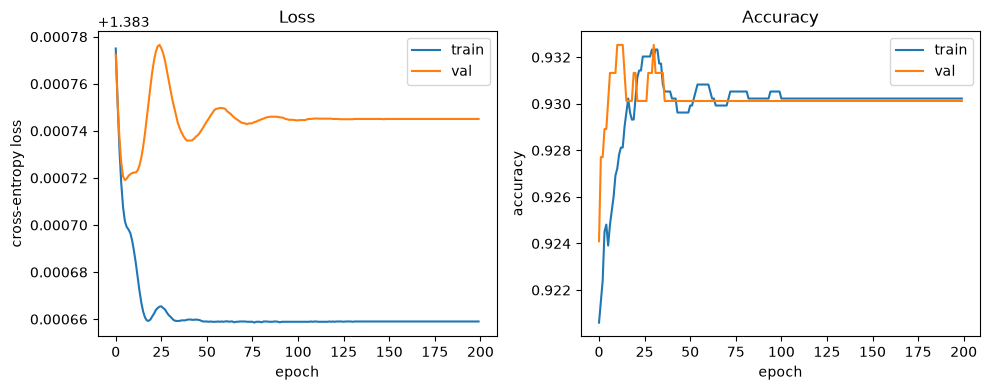

learned scale mixture weights:
  coarse (length_scale=0.40): weight=0.161
  medium (length_scale=0.15): weight=0.254
    fine (length_scale=0.05): weight=0.585


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

fig.tight_layout()
plt.show()

learned_weights = F.softmax(model.scale_logits, dim=0).detach().numpy()
print("learned scale mixture weights:")
for scale_name, length_scale, weight in zip(
    DEFAULT_LENGTH_SCALES.keys(), DEFAULT_LENGTH_SCALES.values(), learned_weights
):
    print(f"  {scale_name:>6s} (length_scale={length_scale:.2f}): weight={weight:.3f}")

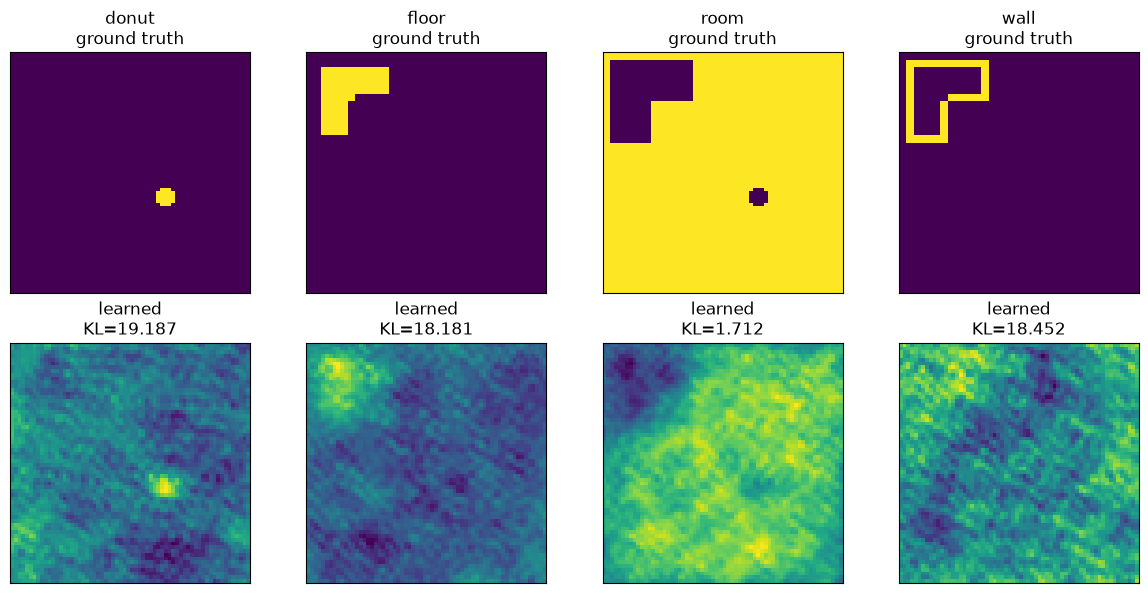

{'donut': 19.186668870174394,
 'floor': 18.18135456245401,
 'room': 1.7124423303042438,
 'wall': 18.45205732560698}

In [8]:
from multiscalessps.metrics import kl_divergence

H, W = room.grid_size
grid_coords = np.array(
    [room.cell_to_coord(i, j) for i in range(H) for j in range(W)], dtype=np.float32
)
grid_points = torch.tensor(grid_coords, device=device)

with torch.no_grad():
    final_memory = model.build_memory(train_points, train_labels)
    grid_scores = model.score_classes(final_memory, grid_points)
    grid_probs = F.softmax(grid_scores, dim=-1).numpy()

gt_maps = room.label_probability_maps()
eps = 1e-12
est_maps = {}
for name, idx in name_to_idx.items():
    m = grid_probs[:, idx].reshape(H, W) + eps
    est_maps[name] = m / m.sum()

kl_per_label = {
    label: kl_divergence(est_maps[label], gt_maps[label]) for label in gt_maps if label in est_maps
}

(xmin, xmax), (ymin, ymax) = room.bounds
extent = (xmin, xmax, ymin, ymax)
labels_sorted = sorted(gt_maps, key=lambda label: label)

fig, axes = plt.subplots(2, len(labels_sorted), figsize=(3 * len(labels_sorted), 6))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(est_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"learned\nKL={kl_per_label[label]:.3f}")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

fig.tight_layout()
plt.show()

kl_per_label

## Per-class normalization

The KL results above are lopsided: `room` (the ~89%-majority class) gets a
low KL, while the sparser classes get much higher KL. One likely cause:
`build_memory`'s default (`normalize_by_class=False`) sums every point's
record with equal weight, so `room`'s ~3000 training points dominate the
memory's energy purely by count, drowning out the rarer classes' signal.

Retrain an otherwise-identical model with `normalize_by_class=True`: each
class's records are summed and unit-normalized *before* being added to the
memory, so every class contributes equally regardless of how many points it
had.

In [9]:
torch.manual_seed(0)

model_norm = MultiScaleFHRRMap(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()),
    device=device,
)

optimizer_norm = torch.optim.Adam(model_norm.parameters(), lr=0.05)

history_norm = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(n_epochs):
    optimizer_norm.zero_grad()
    memory = model_norm.build_memory(train_points, train_labels, normalize_by_class=True)
    train_scores = model_norm.score_classes(memory, train_points)
    train_loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    train_loss.backward()
    optimizer_norm.step()

    with torch.no_grad():
        memory = model_norm.build_memory(train_points, train_labels, normalize_by_class=True)
        val_scores = model_norm.score_classes(memory, val_points)
        val_loss = F.cross_entropy(val_scores, val_labels, weight=class_weights)
        train_acc = (train_scores.argmax(-1) == train_labels).float().mean().item()
        val_acc = (val_scores.argmax(-1) == val_labels).float().mean().item()

    history_norm["train_loss"].append(train_loss.item())
    history_norm["val_loss"].append(val_loss.item())
    history_norm["train_acc"].append(train_acc)
    history_norm["val_acc"].append(val_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(
            f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  val_loss={val_loss.item():.4f}  "
            f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}"
        )

learned_weights_norm = F.softmax(model_norm.scale_logits, dim=0).detach().numpy()
print("learned scale mixture weights (normalize_by_class=True):")
for scale_name, length_scale, weight in zip(
    DEFAULT_LENGTH_SCALES.keys(), DEFAULT_LENGTH_SCALES.values(), learned_weights_norm
):
    print(f"  {scale_name:>6s} (length_scale={length_scale:.2f}): weight={weight:.3f}")

epoch    0  train_loss=1.3794  val_loss=1.3795  train_acc=0.832  val_acc=0.837


epoch   20  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.837


epoch   40  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.837


epoch   60  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.837


epoch   80  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839


...

epoch  120  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839


epoch  140  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839


epoch  160  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839


epoch  180  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839


epoch  199  train_loss=1.3794  val_loss=1.3795  train_acc=0.837  val_acc=0.839
learned scale mixture weights (normalize_by_class=True):
  coarse (length_scale=0.40): weight=0.315
  medium (length_scale=0.15): weight=0.351
    fine (length_scale=0.05): weight=0.334


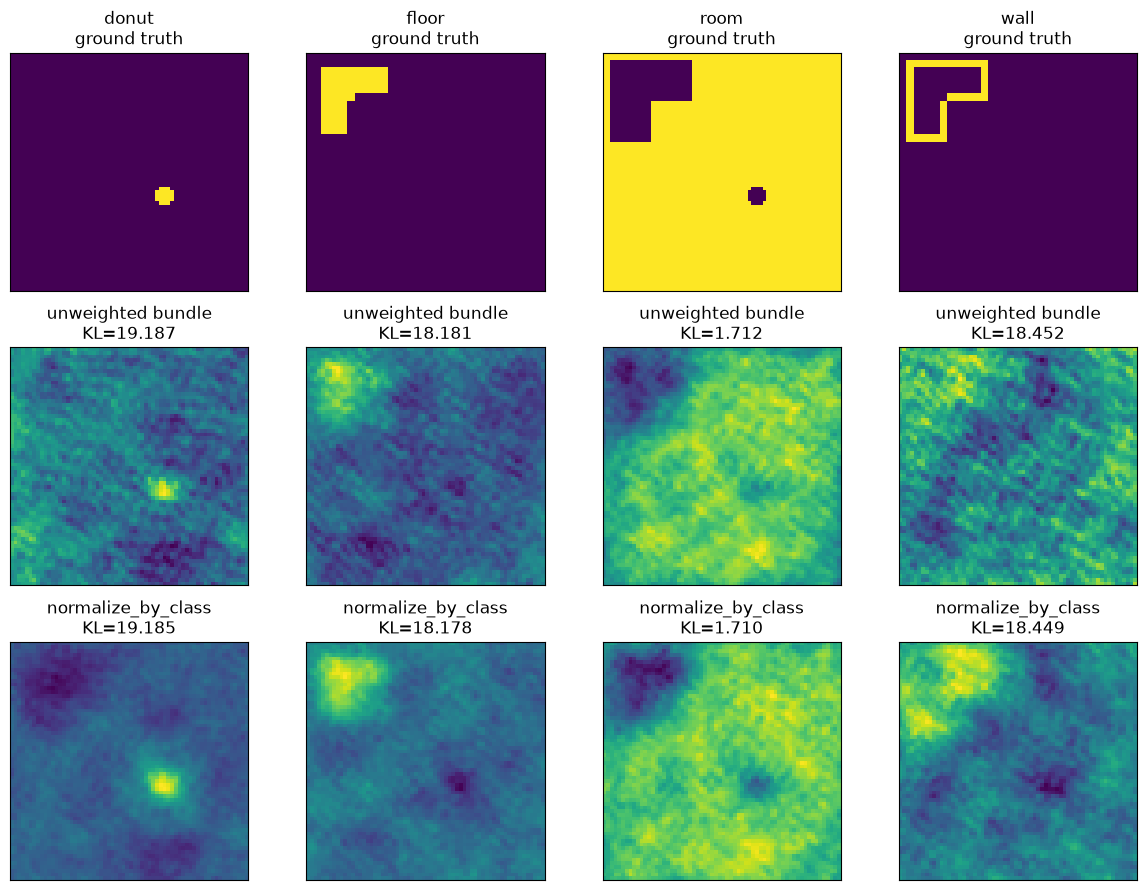

 label   KL (unweighted)   KL (normalize_by_class)
 donut            19.187                    19.185
 floor            18.181                    18.178
  room             1.712                     1.710
  wall            18.452                    18.449


In [10]:
with torch.no_grad():
    final_memory_norm = model_norm.build_memory(train_points, train_labels, normalize_by_class=True)
    grid_scores_norm = model_norm.score_classes(final_memory_norm, grid_points)
    grid_probs_norm = F.softmax(grid_scores_norm, dim=-1).numpy()

est_maps_norm = {}
for name, idx in name_to_idx.items():
    m = grid_probs_norm[:, idx].reshape(H, W) + eps
    est_maps_norm[name] = m / m.sum()

kl_per_label_norm = {
    label: kl_divergence(est_maps_norm[label], gt_maps[label])
    for label in gt_maps
    if label in est_maps_norm
}

fig, axes = plt.subplots(3, len(labels_sorted), figsize=(3 * len(labels_sorted), 9))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(est_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"unweighted bundle\nKL={kl_per_label[label]:.3f}")
    axes[2, col].imshow(est_maps_norm[label], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"normalize_by_class\nKL={kl_per_label_norm[label]:.3f}")
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'KL (unweighted)':>16s}  {'KL (normalize_by_class)':>24s}")
for label in labels_sorted:
    print(f"{label:>6s}  {kl_per_label[label]:>16.3f}  {kl_per_label_norm[label]:>24.3f}")

## Comparison: a per-class continuous length scale instead of a discrete mixture

`MultiScaleFHRRMap` gives every class a learned *mixture* over a fixed set
of discrete length scales (`scale_logits`, shape `(num_scales,)` shared
across classes). An alternative: drop the discrete scale set entirely and
give each class its own single continuous length scale (`(num_classes,)`
parameters, one shared `axis_phase`, constrained positive via `softplus`).
This is more parameter-efficient and maps directly onto `RoomEnv`'s
`label_to_scale` policy (each label really does have one "true" scale) — but
it means gradient descent has to directly navigate a periodic, non-convex
loss surface (as a class's length scale shrinks, its phase wraps around
faster, so the loss oscillates rather than varying smoothly), instead of
just re-weighting a fixed set of already-good encodings.

In [11]:
class PerClassScaleFHRRMap(nn.Module):
    """Like MultiScaleFHRRMap, but each class has one learned continuous
    length scale instead of a shared mixture over a fixed discrete set."""

    def __init__(self, dim, spatial_dim, num_classes, init_length_scale=0.15, device="cpu"):
        super().__init__()
        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes

        axis_phase = 2 * torch.pi * torch.rand(spatial_dim, dim, device=device) - torch.pi
        class_phase = 2 * torch.pi * torch.rand(num_classes, dim, device=device) - torch.pi
        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("class_vecs", torch.exp(1j * class_phase))

        # Learnable per-class length scale, constrained positive via softplus
        # and initialized so softplus(raw_length_scale) == init_length_scale.
        raw_init = torch.full((num_classes,), float(init_length_scale)).expm1().log()
        self.raw_length_scale = nn.Parameter(raw_init)

    @property
    def length_scale(self):
        return F.softplus(self.raw_length_scale)

    def build_memory(self, points, labels, point_weights=None):
        """
        points: [N, spatial_dim]
        labels: [N]
        point_weights: optional [N]
        returns memory: [D]
        """
        ls = self.length_scale[labels]  # [N], each point's own class's length scale
        scaled_phase = self.axis_phase[None, :, :] / ls[:, None, None]  # [N, spatial_dim, dim]
        phase = torch.einsum("nj,njd->nd", points, scaled_phase)
        pos = torch.exp(1j * phase)  # [N, D]

        class_vec = self.class_vecs[labels]  # [N, D]
        atoms = pos * class_vec
        if point_weights is not None:
            atoms = atoms * point_weights[:, None]

        memory = atoms.sum(dim=0)
        memory = memory / torch.linalg.norm(memory)
        return memory

    def score_classes(self, memory, query_points):
        """
        memory: [D]
        query_points: [N, spatial_dim]
        returns: class scores [N, C]
        """
        ls = self.length_scale  # [C]
        scaled_phase = self.axis_phase[None, :, :] / ls[:, None, None]  # [C, spatial_dim, dim]
        phase = torch.einsum("nj,cjd->ncd", query_points, scaled_phase)  # [N, C, D]
        pos = torch.exp(1j * phase)

        probes = pos * self.class_vecs[None, :, :]  # [N, C, D]
        sims = torch.real(
            torch.sum(torch.conj(probes) * memory[None, None, :], dim=-1)
        ) / self.dim  # [N, C]
        return sims

In [12]:
torch.manual_seed(0)

model_pc = PerClassScaleFHRRMap(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    init_length_scale=DEFAULT_LENGTH_SCALES["medium"],
    device=device,
)

optimizer_pc = torch.optim.Adam(model_pc.parameters(), lr=0.05)

history_pc = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "length_scale": []}

for epoch in range(n_epochs):
    optimizer_pc.zero_grad()
    memory = model_pc.build_memory(train_points, train_labels)
    train_scores = model_pc.score_classes(memory, train_points)
    train_loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    train_loss.backward()
    optimizer_pc.step()

    with torch.no_grad():
        memory = model_pc.build_memory(train_points, train_labels)
        val_scores = model_pc.score_classes(memory, val_points)
        val_loss = F.cross_entropy(val_scores, val_labels, weight=class_weights)
        train_acc = (train_scores.argmax(-1) == train_labels).float().mean().item()
        val_acc = (val_scores.argmax(-1) == val_labels).float().mean().item()

    history_pc["train_loss"].append(train_loss.item())
    history_pc["val_loss"].append(val_loss.item())
    history_pc["train_acc"].append(train_acc)
    history_pc["val_acc"].append(val_acc)
    history_pc["length_scale"].append(model_pc.length_scale.detach().numpy().copy())

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        ls_str = ", ".join(
            f"{name}={ls:.3f}" for name, ls in zip(label_names, history_pc["length_scale"][-1])
        )
        print(
            f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  val_loss={val_loss.item():.4f}  "
            f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  length_scales: {ls_str}"
        )

epoch    0  train_loss=1.3846  val_loss=1.3846  train_acc=0.953  val_acc=0.942  length_scales: donut=0.157, floor=0.157, room=0.143, wall=0.157


epoch   20  train_loss=1.3816  val_loss=1.3815  train_acc=0.423  val_acc=0.327  length_scales: donut=0.364, floor=0.363, room=0.057, wall=0.122


epoch   40  train_loss=1.3810  val_loss=1.3808  train_acc=0.349  val_acc=0.288  length_scales: donut=0.470, floor=0.399, room=0.029, wall=0.122


epoch   60  train_loss=1.3808  val_loss=1.3808  train_acc=0.308  val_acc=0.228  length_scales: donut=0.554, floor=0.305, room=0.027, wall=0.121


epoch   80  train_loss=1.3808  val_loss=1.3808  train_acc=0.277  val_acc=0.206  length_scales: donut=0.679, floor=0.303, room=0.028, wall=0.121


...

epoch  120  train_loss=1.3808  val_loss=1.3808  train_acc=0.270  val_acc=0.199  length_scales: donut=0.694, floor=0.309, room=0.028, wall=0.121


epoch  140  train_loss=1.3808  val_loss=1.3808  train_acc=0.271  val_acc=0.199  length_scales: donut=0.693, floor=0.309, room=0.028, wall=0.122


epoch  160  train_loss=1.3808  val_loss=1.3808  train_acc=0.270  val_acc=0.198  length_scales: donut=0.695, floor=0.309, room=0.028, wall=0.122


epoch  180  train_loss=1.3808  val_loss=1.3808  train_acc=0.270  val_acc=0.198  length_scales: donut=0.695, floor=0.309, room=0.028, wall=0.122


epoch  199  train_loss=1.3808  val_loss=1.3808  train_acc=0.270  val_acc=0.198  length_scales: donut=0.695, floor=0.309, room=0.028, wall=0.122


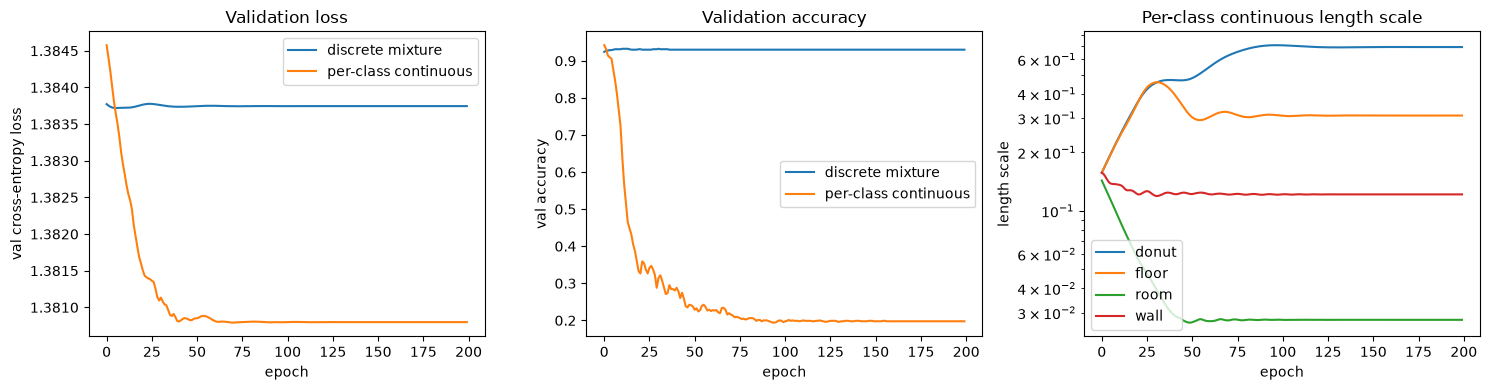

final val accuracy: discrete mixture=0.930, per-class continuous=0.198


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["val_loss"], label="discrete mixture")
axes[0].plot(history_pc["val_loss"], label="per-class continuous")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("val cross-entropy loss")
axes[0].set_title("Validation loss")
axes[0].legend()

axes[1].plot(history["val_acc"], label="discrete mixture")
axes[1].plot(history_pc["val_acc"], label="per-class continuous")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val accuracy")
axes[1].set_title("Validation accuracy")
axes[1].legend()

length_scale_history = np.array(history_pc["length_scale"])  # [epoch, num_classes]
for i, name in enumerate(label_names):
    axes[2].plot(length_scale_history[:, i], label=name)
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("length scale")
axes[2].set_yscale("log")
axes[2].set_title("Per-class continuous length scale")
axes[2].legend()

fig.tight_layout()
plt.show()

print(
    f"final val accuracy: discrete mixture={history['val_acc'][-1]:.3f}, "
    f"per-class continuous={history_pc['val_acc'][-1]:.3f}"
)

**Takeaway.** Despite having more targeted capacity (one scale per class,
matching `RoomEnv`'s actual `label_to_scale` policy), the per-class
continuous version's validation loss decreases while its accuracy collapses.
The optimizer drives `room`'s length scale down toward extremely fine
values relative to the ~2-unit domain; at that scale `room`'s ~3000 training
points sum almost incoherently, so `room`'s contribution to the
L2-normalized memory shrinks. The inverse-frequency-weighted loss doesn't
penalize this (it averages per class, and `room` is only one of four terms),
but raw accuracy — dominated by the majority class — craters. The discrete
mixture avoids this because it can only re-weight a fixed set of already-reasonable
encodings; it can't drive any single class into a degenerate, aliased regime.

## Temperature calibration

Going back to the original discrete-mixture model (`model`, trained above):
its raw `score_classes` output has a tiny magnitude (std around 0.003),
because its `/ self.dim` divisor is far bigger than the actual signal it's
normalizing. A softmax at temperature=1 over scores that small is nearly
uniform everywhere — good enough for argmax-based accuracy (which only needs
the tiny ranking edge to survive), but it's why every KL comparison so far
has looked stuck at the same ~19/18/1.7/18 floor regardless of what else we
changed: KL depends on the actual probability magnitudes, and those were
always collapsed toward 1/C.

`predict_proba(memory, query_points, temperature=...)` (mirroring
`VSASpatialMemory.query`'s existing `temperature` parameter in
`models/baseline.py`) rescales the scores before the softmax. Calibrate
`temperature` by sweeping it against **validation cross-entropy** (not
against the KL metric itself, to avoid fitting the calibration directly to
the evaluation we care about) and picking the minimizer.

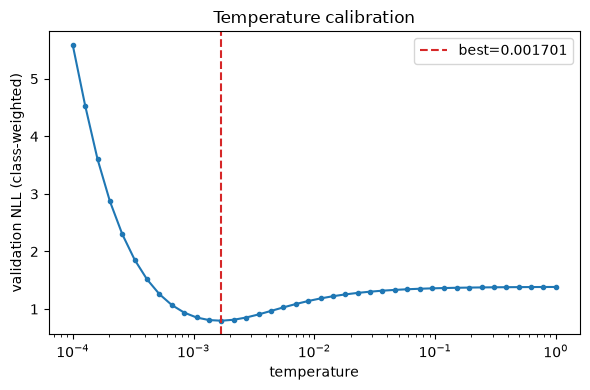

calibrated temperature: 0.001701


In [14]:
with torch.no_grad():
    final_memory = model.build_memory(train_points, train_labels)

    temperatures = np.logspace(-4, 0, 40)
    val_nll = []
    for t in temperatures:
        probs = model.predict_proba(final_memory, val_points, temperature=t)
        nll = F.nll_loss(torch.log(probs + 1e-12), val_labels, weight=class_weights).item()
        val_nll.append(nll)

    best_temperature = temperatures[int(np.argmin(val_nll))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(temperatures, val_nll, marker="o", markersize=3)
ax.axvline(best_temperature, color="tab:red", linestyle="--", label=f"best={best_temperature:.4g}")
ax.set_xscale("log")
ax.set_xlabel("temperature")
ax.set_ylabel("validation NLL (class-weighted)")
ax.set_title("Temperature calibration")
ax.legend()
fig.tight_layout()
plt.show()

print(f"calibrated temperature: {best_temperature:.4g}")

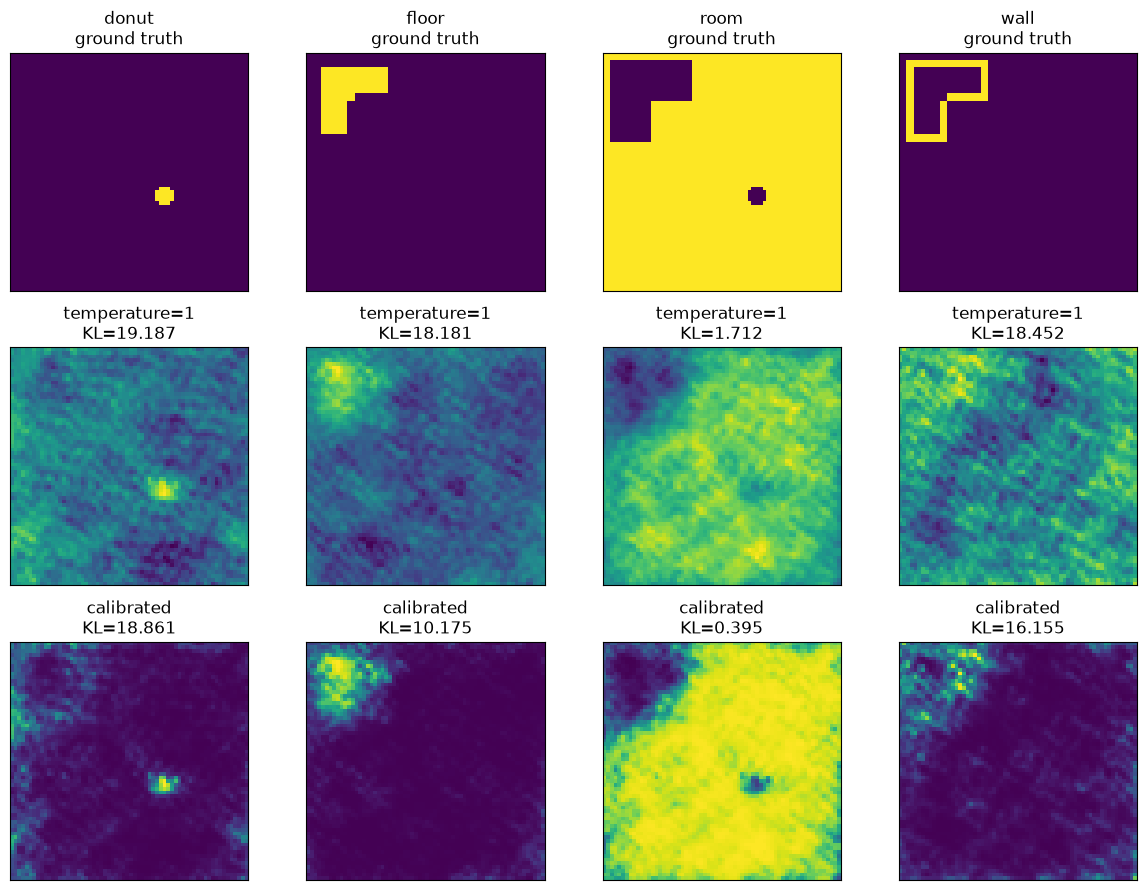

 label   KL (temperature=1)  KL (calibrated)
 donut               19.187           18.861
 floor               18.181           10.175
  room                1.712            0.395
  wall               18.452           16.155


In [15]:
with torch.no_grad():
    grid_probs_calibrated = model.predict_proba(final_memory, grid_points, temperature=best_temperature).numpy()

est_maps_calibrated = {}
for name, idx in name_to_idx.items():
    m = grid_probs_calibrated[:, idx].reshape(H, W) + eps
    est_maps_calibrated[name] = m / m.sum()

kl_per_label_calibrated = {
    label: kl_divergence(est_maps_calibrated[label], gt_maps[label]) for label in gt_maps
}

fig, axes = plt.subplots(3, len(labels_sorted), figsize=(3 * len(labels_sorted), 9))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(est_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"temperature=1\nKL={kl_per_label[label]:.3f}")
    axes[2, col].imshow(est_maps_calibrated[label], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"calibrated\nKL={kl_per_label_calibrated[label]:.3f}")
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'KL (temperature=1)':>19s}  {'KL (calibrated)':>15s}")
for label in labels_sorted:
    print(f"{label:>6s}  {kl_per_label[label]:>19.3f}  {kl_per_label_calibrated[label]:>15.3f}")

**Takeaway.** Calibrating the temperature (no retraining, same `model` and
memory as every earlier section) drops `room`'s KL by 77% and `floor`'s by
44% — signal that was there all along but hidden by a softmax operating on
scores 2-3 orders of magnitude smaller than it should have been. This is
also why the per-class normalization and per-class scale mixture experiments
earlier looked like they did nothing: both changed how the memory was built,
but the KL evaluation was reading it through the same over-flattened
softmax, which masked whatever those changes actually did.

`donut` barely moves (19.187 → 18.861). With only 64 training points, its
signal is genuinely weak rather than hidden — sharpening the softmax
amplifies noise as readily as signal when there's this little of the latter
to find. Fixing `donut` specifically would need a different lever (more
representative points for it, or a memory architecture with better
per-class capacity), not a scoring/calibration fix.

## A separate memory per class

Everything above bound every point into **one shared memory vector**,
using `class_vecs` to keep each class's records distinguishable within that
single superposition. That shared vector is exactly where the crosstalk
came from: `donut`'s 64 records shared space with `room`'s ~3000, and
querying required unbinding a specific class back out of a memory dominated
by everyone else's contributions.

An alternative: give every class its **own** memory — just a bundle of that
class's own position encodings, with no class binding at all (a memory's
identity is which class it belongs to, not something bound into a shared
vector). Querying becomes correlating a query point's encoding against all
`C` memories directly. This keeps the same multi-scale mixture (`scale_vecs`
+ a shared `scale_logits`, exactly as trained above), but removes cross-class
interference entirely — the only crosstalk left is *within* a class's own
points, which is unavoidable (and much less of a problem, since a broad
class like `room` doesn't need to recall individual points, just decode the
right region).

In [16]:
class PerClassMemoryFHRRMap(nn.Module):
    """One memory per class -- a bundle of just that class's own position
    encodings, no class binding at all. Still keeps the shared multi-scale
    mixture (`scale_vecs` + `scale_logits`) from `MultiScaleFHRRMap`."""

    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu"):
        super().__init__()
        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        axis_phase = 2 * torch.pi * torch.rand(
            self.num_scales, spatial_dim, dim, device=device
        ) - torch.pi
        scale_phase = 2 * torch.pi * torch.rand(
            self.num_scales, dim, device=device
        ) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        # Learnable scale mixture weights, shared across classes (as in MultiScaleFHRRMap).
        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales))

    def encode_position(self, x):
        """
        x: [N, spatial_dim]
        returns: [N, K, D]
        """
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memories(self, points, labels, point_weights=None):
        """
        points: [N, spatial_dim]
        labels: [N]
        point_weights: optional [N]
        returns memories: [C, D], one bundle per class, each independently
            unit-normalized (there's no shared vector to normalize globally
            anymore -- every class already gets its own, so this is always
            the per-class-normalized behavior by construction).
        """
        pos = self.encode_position(points)  # [N, K, D]

        scale_weights = F.softmax(self.scale_logits, dim=0)  # [K]
        atoms = pos * self.scale_vecs[None, :, :] * scale_weights[None, :, None]  # [N, K, D]

        if point_weights is not None:
            atoms = atoms * point_weights[:, None, None]

        records = atoms.sum(dim=1)  # [N, D] -- per-point record, summed over scales

        memories = torch.zeros(
            self.num_classes, self.dim, dtype=records.dtype, device=records.device
        )
        for c in range(self.num_classes):
            class_sum = records[labels == c].sum(dim=0)  # [D]
            memories[c] = class_sum / torch.linalg.norm(class_sum)
        return memories

    def score_classes(self, memories, query_points):
        """
        memories: [C, D]
        query_points: [N, spatial_dim]
        returns: class scores [N, C]
        """
        pos = self.encode_position(query_points)  # [N, K, D]
        probes = pos * self.scale_vecs[None, :, :]  # [N, K, D]

        # correlate each scale's probe against every class's memory directly,
        # without ever materializing an [N, K, C, D] tensor
        sims = torch.real(
            torch.einsum("nkd,cd->nkc", probes, torch.conj(memories))
        ) / self.dim  # [N, K, C]

        return sims.sum(dim=1)  # [N, C] -- sum evidence over scales

    def predict_proba(self, memories, query_points, temperature=1.0):
        """Class probabilities at each query point (see MultiScaleFHRRMap.predict_proba)."""
        scores = self.score_classes(memories, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)

In [17]:
class PerClassMemoryFHRRMapLearnedTemp(PerClassMemoryFHRRMap):
    """PerClassMemoryFHRRMap with a single learnable temperature (shared across
    classes, since score_classes returns one score matrix) folded into the
    training loss, for the same reason as MultiScaleFHRRMapLearnedTemp above."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memories, query_points):
        return self.score_classes(memories, query_points) / self.temperature

In [18]:
torch.manual_seed(0)

model_pcmem = PerClassMemoryFHRRMap(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()),
    device=device,
)

optimizer_pcmem = torch.optim.Adam(model_pcmem.parameters(), lr=0.05)

history_pcmem = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(n_epochs):
    optimizer_pcmem.zero_grad()
    memories = model_pcmem.build_memories(train_points, train_labels)
    train_scores = model_pcmem.score_classes(memories, train_points)
    train_loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    train_loss.backward()
    optimizer_pcmem.step()

    with torch.no_grad():
        memories = model_pcmem.build_memories(train_points, train_labels)
        val_scores = model_pcmem.score_classes(memories, val_points)
        val_loss = F.cross_entropy(val_scores, val_labels, weight=class_weights)
        train_acc = (train_scores.argmax(-1) == train_labels).float().mean().item()
        val_acc = (val_scores.argmax(-1) == val_labels).float().mean().item()

    history_pcmem["train_loss"].append(train_loss.item())
    history_pcmem["val_loss"].append(val_loss.item())
    history_pcmem["train_acc"].append(train_acc)
    history_pcmem["val_acc"].append(val_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(
            f"epoch {epoch:4d}  train_loss={train_loss.item():.4f}  val_loss={val_loss.item():.4f}  "
            f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}"
        )

learned_weights_pcmem = F.softmax(model_pcmem.scale_logits, dim=0).detach().numpy()
print("learned scale mixture weights:")
for scale_name, length_scale, weight in zip(
    DEFAULT_LENGTH_SCALES.keys(), DEFAULT_LENGTH_SCALES.values(), learned_weights_pcmem
):
    print(f"  {scale_name:>6s} (length_scale={length_scale:.2f}): weight={weight:.3f}")

# Direct check: does this model actually recall donut's own training points now
# (it was at chance level, ~0.25, for the shared-memory model)?
with torch.no_grad():
    memories = model_pcmem.build_memories(train_points, train_labels)
    donut_idx = name_to_idx["donut"]
    train_donut_pts = train_points[train_labels == donut_idx]
    donut_scores = model_pcmem.score_classes(memories, train_donut_pts)
    print(
        f"\nargmax==donut at donut's own training points: "
        f"{(donut_scores.argmax(-1) == donut_idx).float().mean().item():.3f}"
    )

epoch    0  train_loss=1.3724  val_loss=1.3727  train_acc=0.853  val_acc=0.867


epoch   20  train_loss=1.3724  val_loss=1.3727  train_acc=0.855  val_acc=0.866


epoch   40  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch   60  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch   80  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


...

epoch  120  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch  140  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch  160  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch  180  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867


epoch  199  train_loss=1.3724  val_loss=1.3727  train_acc=0.857  val_acc=0.867
learned scale mixture weights:
  coarse (length_scale=0.40): weight=0.310
  medium (length_scale=0.15): weight=0.342
    fine (length_scale=0.05): weight=0.348

argmax==donut at donut's own training points: 1.000


calibrated temperature: 0.002759


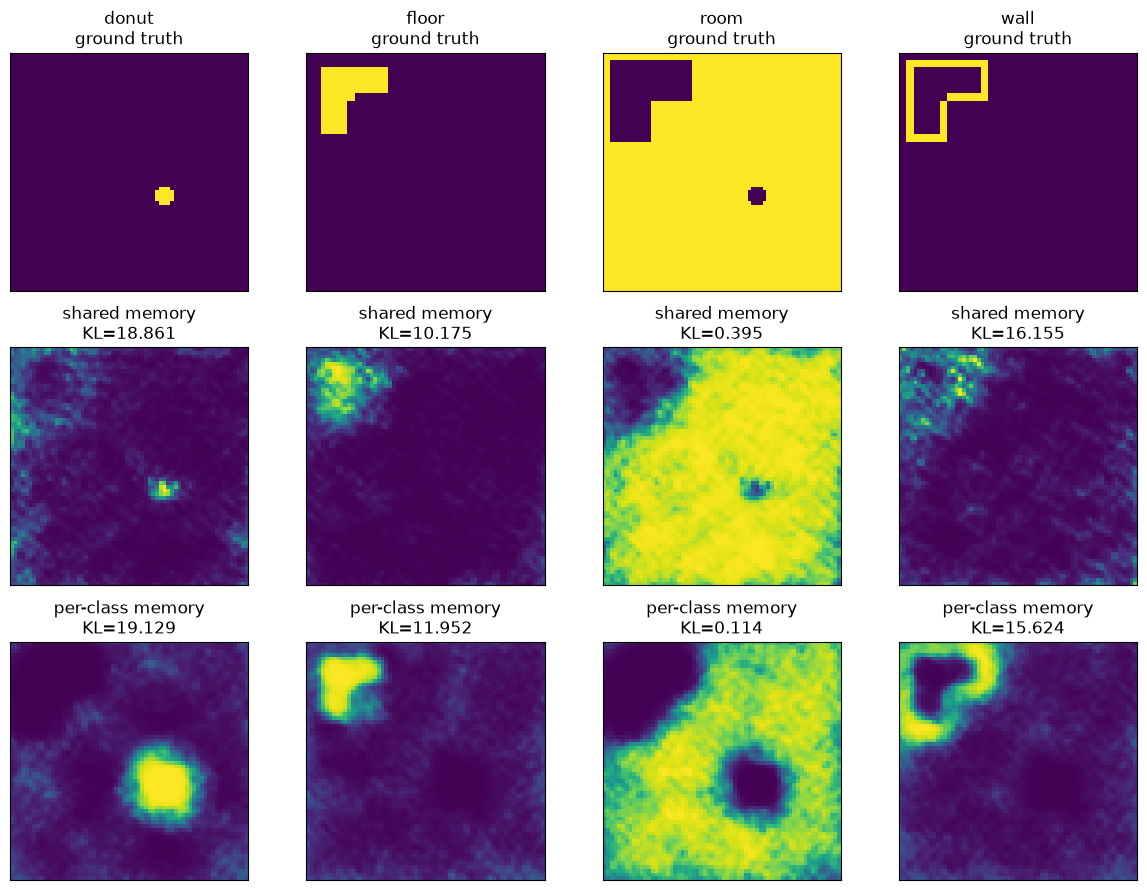

 label   KL (shared memory)   KL (per-class memory)
 donut               18.861                  19.129
 floor               10.175                  11.952
  room                0.395                   0.114
  wall               16.155                  15.624


In [19]:
with torch.no_grad():
    final_memories_pcmem = model_pcmem.build_memories(train_points, train_labels)

    temperatures_pcmem = np.logspace(-4, 1, 60)
    val_nll_pcmem = []
    for t in temperatures_pcmem:
        probs = model_pcmem.predict_proba(final_memories_pcmem, val_points, temperature=t)
        nll = F.nll_loss(torch.log(probs + 1e-12), val_labels, weight=class_weights).item()
        val_nll_pcmem.append(nll)
    best_temperature_pcmem = temperatures_pcmem[int(np.argmin(val_nll_pcmem))]

    grid_probs_pcmem = model_pcmem.predict_proba(
        final_memories_pcmem, grid_points, temperature=best_temperature_pcmem
    ).numpy()

print(f"calibrated temperature: {best_temperature_pcmem:.4g}")

est_maps_pcmem = {}
for name, idx in name_to_idx.items():
    m = grid_probs_pcmem[:, idx].reshape(H, W) + eps
    est_maps_pcmem[name] = m / m.sum()

kl_per_label_pcmem = {
    label: kl_divergence(est_maps_pcmem[label], gt_maps[label]) for label in gt_maps
}

fig, axes = plt.subplots(3, len(labels_sorted), figsize=(3 * len(labels_sorted), 9))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(est_maps_calibrated[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"shared memory\nKL={kl_per_label_calibrated[label]:.3f}")
    axes[2, col].imshow(est_maps_pcmem[label], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"per-class memory\nKL={kl_per_label_pcmem[label]:.3f}")
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'KL (shared memory)':>19s}  {'KL (per-class memory)':>22s}")
for label in labels_sorted:
    print(f"{label:>6s}  {kl_per_label_calibrated[label]:>19.3f}  {kl_per_label_pcmem[label]:>22.3f}")

In [20]:
# Raw val accuracy (0.867) is actually *lower* than the shared-memory model's
# (0.930) -- and even below the 0.894 "always predict room" baseline. Check
# per-class recall to see whether that's actually a bad sign, or the expected
# cost of no longer defaulting to "room" for everything.
with torch.no_grad():
    val_scores_shared = model.score_classes(final_memory, val_points)
    val_scores_pcmem = model_pcmem.score_classes(final_memories_pcmem, val_points)

print(f"{'label':>6s}  {'recall (shared)':>16s}  {'recall (per-class memory)':>26s}")
for name, idx in name_to_idx.items():
    mask = val_labels == idx
    recall_shared = (val_scores_shared[mask].argmax(-1) == idx).float().mean().item()
    recall_pcmem = (val_scores_pcmem[mask].argmax(-1) == idx).float().mean().item()
    print(f"{name:>6s}  {recall_shared:>16.3f}  {recall_pcmem:>26.3f}")

 label   recall (shared)   recall (per-class memory)
 donut             0.500                       1.000
 floor             0.927                       0.878
  room             0.974                       0.871
  wall             0.097                       0.710


### Does a learned temperature change whether the per-class mixture moves?

`baseline_comparison.ipynb` left this as an open question: does the
per-class model's `scale_logits` stay near-uniform because there's genuinely
no marginal benefit to sharpening it once each class has its own clean
memory, or because the untempered loss gives it no usable gradient? Retrain
`model_pcmem` with the learned-temperature loss and compare mixtures
directly.

In [21]:
torch.manual_seed(0)
model_pcmem_lt = PerClassMemoryFHRRMapLearnedTemp(
    dim=1024,
    spatial_dim=2,
    num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()),
    device=device,
)

history_pcmem_lt = train_learned_temp(
    model_pcmem_lt, model_pcmem_lt.build_memories, "scaled_scores",
    train_points, train_labels, val_points, val_labels, class_weights,
)

learned_weights_pcmem_lt = F.softmax(model_pcmem_lt.scale_logits, dim=0).detach().numpy()
print(f"\nlearned temperature: {model_pcmem_lt.temperature.item():.4g}")
print("learned scale mixture weights (tempered):")
for scale_name, length_scale, weight in zip(
    DEFAULT_LENGTH_SCALES.keys(), DEFAULT_LENGTH_SCALES.values(), learned_weights_pcmem_lt
):
    print(f"  {scale_name:>6s} (length_scale={length_scale:.2f}): weight={weight:.3f}")
print("\nmixture deviation from uniform (1/3), max abs:")
print(f"  untempered: {np.abs(learned_weights_pcmem - 1/3).max():.4f}")
print(f"  tempered:   {np.abs(learned_weights_pcmem_lt - 1/3).max():.4f}")

epoch    0  train_loss=0.6044  val_loss=0.6029  train_acc=0.853  val_acc=0.867  temperature=0.009512


epoch   20  train_loss=0.3059  val_loss=0.3843  train_acc=0.897  val_acc=0.893  temperature=0.00359


epoch   40  train_loss=0.1770  val_loss=0.3558  train_acc=0.912  val_acc=0.894  temperature=0.001653


epoch   60  train_loss=0.1391  val_loss=0.3917  train_acc=0.903  val_acc=0.867  temperature=0.001009


epoch   80  train_loss=0.1329  val_loss=0.4304  train_acc=0.894  val_acc=0.854  temperature=0.0007972


...

epoch  120  train_loss=0.1326  val_loss=0.4461  train_acc=0.892  val_acc=0.842  temperature=0.0007412


epoch  140  train_loss=0.1326  val_loss=0.4441  train_acc=0.892  val_acc=0.843  temperature=0.0007477


epoch  160  train_loss=0.1326  val_loss=0.4433  train_acc=0.892  val_acc=0.845  temperature=0.0007505


epoch  180  train_loss=0.1326  val_loss=0.4432  train_acc=0.892  val_acc=0.845  temperature=0.0007506


epoch  199  train_loss=0.1326  val_loss=0.4433  train_acc=0.892  val_acc=0.845  temperature=0.0007502

learned temperature: 0.0007502
learned scale mixture weights (tempered):
  coarse (length_scale=0.40): weight=0.033
  medium (length_scale=0.15): weight=0.134
    fine (length_scale=0.05): weight=0.834

mixture deviation from uniform (1/3), max abs:
  untempered: 0.0230
  tempered:   0.5004


**Takeaway.** Per-class memories fix exactly the problem this whole
investigation traced back to: `donut` goes from chance-level (0.500 recall,
worse than a coin flip on a binary in/out decision) to **perfect recall
(1.000)** on its own class, and `wall` climbs from 0.097 to 0.710. `room`'s
KL drops further too (0.395 → 0.114), since its own memory is no longer
diluted by anything else. The cost is a small recall dip for the two common
classes (`room` 0.974 → 0.871, `floor` 0.927 → 0.878) — and because `room`
alone is 89% of the validation set, that dip is enough to drag the raw
aggregate accuracy down (0.930 → 0.867), even though per-class performance
improved almost across the board. This is the clearest illustration all
session of why aggregate accuracy was always a misleading metric here: KL
and per-class recall are what actually reflect the model's spatial
usefulness.

`donut`'s grid KL still barely moves (18.861 → 19.129) despite perfect
recall at its own training points — so it still doesn't generalize to
nearby-but-unseen positions within its own tiny disc. The likely next lever
is that `scale_logits` is still a single mixture *shared* across all four
classes (~31/34/35% coarse/medium/fine); a per-class mixture — which failed
earlier only because of the shared-memory crosstalk and softmax
miscalibration this section fixed — might finally let `donut` push much
further toward the fine scale it actually needs, without those two masking
effects in the way.

**Addendum: does tempering resolve the per-class mixture question?** Compare
the "mixture deviation from uniform" printed just above between the
untempered `model_pcmem` and tempered `model_pcmem_lt`. If the tempered
mixture still stays close to uniform despite the loss now being properly
scaled, that's real support for the "zero-marginal-benefit" reading --
each class's own memory already discriminates well enough that sharpening
the scale mixture has little left to offer. If it moves substantially
instead, the flat mixture was the same untempered-loss artifact seen in
`hierarchical_encoding.ipynb`'s Tier 3, not a genuine ceiling effect.

## Visualizing the learned kernel

`encode_position`'s similarity is translation-invariant: for a single scale
`k`, `real(encode(x)_k . conj(encode(x')_k)) / dim` depends only on the
displacement `x - x'`, not `x` and `x'` separately — it's a stationary
kernel `K_k(delta)`. Binding each scale to its own `scale_vecs[k]` before
summing keeps the different `K_k` from interfering with each other (up to
small finite-`dim` residual noise), so the similarity function a class's
memory actually uses is (approximately) the learned mixture

```
K(delta) = sum_k w_k * K_k(delta),   w = softmax(scale_logits)
```

`model_pcmem`'s `scale_logits` is still **shared** across classes (we found
per-class mixtures didn't help), so there's one learned kernel here, not
four — what differs per class is only which points get bundled through it.

Compute each `K_k` directly from `encode_position` (one reference point at
the origin vs. a grid of displacements), then combine them with the learned
mixture weights.

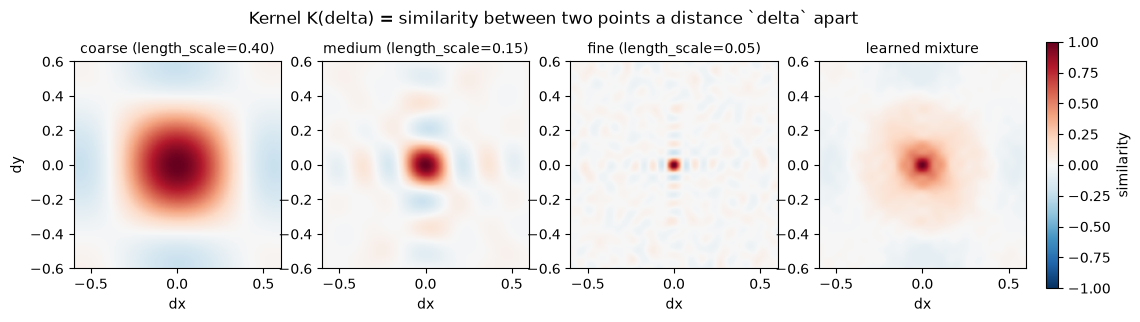

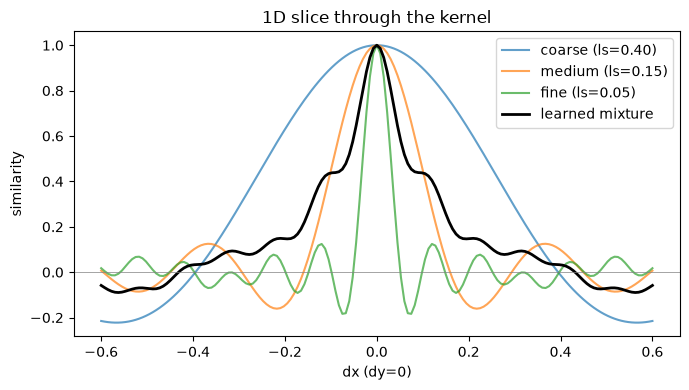

learned mixture weights: {'coarse': np.float32(0.31), 'medium': np.float32(0.342), 'fine': np.float32(0.348)}


In [22]:
with torch.no_grad():
    kernel_extent = 0.6
    n_k = 161
    dxs = np.linspace(-kernel_extent, kernel_extent, n_k)
    dys = np.linspace(-kernel_extent, kernel_extent, n_k)
    DX, DY = np.meshgrid(dxs, dys)
    delta_points = torch.tensor(
        np.stack([DX.ravel(), DY.ravel()], axis=1), dtype=torch.float32
    )

    pos_origin = model_pcmem.encode_position(torch.zeros(1, 2))[0]  # [K, D]
    pos_delta = model_pcmem.encode_position(delta_points)  # [N, K, D]

    # K_k(delta) for each scale k, unweighted -- normalize by dim so this is a
    # proper [-1, 1] similarity, not a raw sum over `dim` unit-modulus terms.
    base_kernels = (
        torch.real(torch.einsum("nkd,kd->nk", pos_delta, torch.conj(pos_origin)))
        / model_pcmem.dim
    ).numpy()  # [N, K]

    learned_weights_kernel = F.softmax(model_pcmem.scale_logits, dim=0).numpy()  # [K]
    combined_kernel = base_kernels @ learned_weights_kernel  # [N]

scale_names = list(DEFAULT_LENGTH_SCALES.keys())
kernels_2d = {name: base_kernels[:, k].reshape(n_k, n_k) for k, name in enumerate(scale_names)}
kernels_2d["learned mixture"] = combined_kernel.reshape(n_k, n_k)

panel_names = scale_names + ["learned mixture"]
fig, axes = plt.subplots(1, len(panel_names), figsize=(3.2 * len(panel_names), 3.2))
kernel_extent_box = (-kernel_extent, kernel_extent, -kernel_extent, kernel_extent)
for ax, name in zip(axes, panel_names):
    im = ax.imshow(
        kernels_2d[name], extent=kernel_extent_box, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1
    )
    title = name if name == "learned mixture" else f"{name} (length_scale={DEFAULT_LENGTH_SCALES[name]:.2f})"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("dx")
    ax.set_aspect("equal")
axes[0].set_ylabel("dy")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="similarity")
fig.suptitle("Kernel K(delta) = similarity between two points a distance `delta` apart")
plt.show()

# 1D slice along dy=0, easier to compare width/shape directly
mid_row = n_k // 2
fig, ax = plt.subplots(figsize=(7, 4))
for name in scale_names:
    ax.plot(dxs, kernels_2d[name][mid_row], label=f"{name} (ls={DEFAULT_LENGTH_SCALES[name]:.2f})", alpha=0.7)
ax.plot(dxs, kernels_2d["learned mixture"][mid_row], label="learned mixture", color="black", linewidth=2)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel("dx (dy=0)")
ax.set_ylabel("similarity")
ax.set_title("1D slice through the kernel")
ax.legend()
fig.tight_layout()
plt.show()

print("learned mixture weights:", dict(zip(scale_names, learned_weights_kernel.round(3))))

**Reading the plot.** Each individual scale is a proper stationary kernel
whose width tracks its `length_scale`: `coarse` is a broad, slowly-decaying
bump (still >0.5 similarity out to `dx=±0.3`), `medium` is narrower with
visible negative sidelobes starting around `dx=±0.15`, and `fine` is a sharp
spike that's already oscillating through zero by `dx=±0.05` — this ringing
is expected for a random-Fourier-feature encoding with a bounded, uniformly
distributed frequency range (it's a Dirichlet/sinc-like kernel, not a smooth
Gaussian).

The **learned mixture** (~31/34/35% coarse/medium/fine) is a sharp central
peak sitting on a broad shoulder: the `fine` and `medium` components give it
a narrow, confident spike right at `dx=0`, while `coarse` contributes the
slowly-decaying base that keeps nearby-but-not-identical points from reading
as completely dissimilar. This is the actual similarity function every
class's memory in `model_pcmem` uses to decide "is this query point close
enough to something I've seen" — and it's the same shape for all four
classes, since `scale_logits` is shared.